##### Copyright 2025 Google LLC.

In [ ]:
# @title Licensed under the Apache License, Version 2.0 (the "License");
# you may not use this file except in compliance with the License.
# You may obtain a copy of the License at
#
# https://www.apache.org/licenses/LICENSE-2.0
#
# Unless required by applicable law or agreed to in writing, software
# distributed under the License is distributed on an "AS IS" BASIS,
# WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
# See the License for the specific language governing permissions and
# limitations under the License.

**Links**

- Doc. API - https://ai.google.dev/gemini-api/docs/quickstart?hl=pt-br
- Playground - https://aistudio.google.com/app/prompts/new_chat
- Chave de API - https://aistudio.google.com/app/api-keys
- Cotas - https://console.cloud.google.com/apis/api/generativelanguage.googleapis.com/quotas


# Get started with the Gemini API: Python

<table class="tfo-notebook-buttons" align="left">
  <td>
    <a target="_blank" href="https://ai.google.dev/gemini-api/docs/get-started/python"><img src="https://ai.google.dev/static/site-assets/images/docs/notebook-site-button.png" height="32" width="32" />View on Google AI</a>
  </td>
  <td>
    <a target="_blank" href="https://colab.research.google.com/github/google/generative-ai-docs/blob/main/site/en/gemini-api/docs/get-started/python.ipynb"><img src="https://www.tensorflow.org/images/colab_logo_32px.png" />Run in Google Colab</a>
  </td>
  <td>
    <a target="_blank" href="https://github.com/google/generative-ai-docs/blob/main/site/en/gemini-api/docs/get-started/python.ipynb"><img src="https://www.tensorflow.org/images/GitHub-Mark-32px.png" />View source on GitHub</a>
  </td>
</table>

This quickstart demonstrates how to use the Python SDK for the Gemini API, which gives you access to Google's Gemini large language models. In this quickstart, you will learn how to:

1. Set up your development environment and API access to use Gemini.
2. Generate text responses from text inputs.
3. Generate text responses from multimodal inputs (text and images).
4. Use Gemini for multi-turn conversations (chat).
5. Use embeddings for large language models.

## Prerequisites

You can run this quickstart in [Google Colab](https://colab.research.google.com/github/google/generative-ai-docs/blob/main/site/en/gemini-api/docs/get-started/python.ipynb), which runs this notebook directly in the browser and does not require additional environment configuration.

Alternatively, to complete this quickstart locally, ensure that your development environment meets the following requirements:

-  Python 3.9+
-  An installation of `jupyter` to run the notebook.

## Setup

### Install the Python SDK

The Python SDK for the Gemini API, is contained in the [`google-generativeai`](https://pypi.org/project/google-generativeai/) package. Install the dependency using pip:

In [ ]:
!pip install -q -U google-generativeai

### Import packages

Import the necessary packages.

In [ ]:
import pathlib
import textwrap

import google.generativeai as genai

from IPython.display import display
from IPython.display import Markdown


def to_markdown(text):
    text = text.replace("•", "  *")
    return Markdown(textwrap.indent(text, "> ", predicate=lambda _: True))

In [ ]:
# Used to securely store your API key
from google.colab import userdata

### Setup your API key

Before you can use the Gemini API, you must first obtain an API key. If you don't already have one, create a key with one click in Google AI Studio.

<a class="button button-primary" href="https://makersuite.google.com/app/apikey" target="_blank" rel="noopener noreferrer">Get an API key</a>

Note that depending on where you are located, you might have to [enable billing](https://ai.google.dev/gemini-api/docs/billing#enable-cloud-billing) since the free tier is not available in [EEA (including EU), the UK, and CH](https://ai.google.dev/gemini-api/docs/billing#is-Gemini-free-in-EEA-UK-CH)

In Colab, add the key to the secrets manager under the "🔑" in the left panel. Give it the name `GEMINI_API_KEY`.

Once you have the API key, pass it to the SDK. You can do this in two ways:

* Put the key in the `GEMINI_API_KEY` environment variable (the SDK will automatically pick it up from there).
* Pass the key to `genai.configure(api_key=...)`

In [ ]:
# Or use `os.getenv('GEMINI_API_KEY')` to fetch an environment variable.
GOOGLE_API_KEY = userdata.get("GEMINI_API_KEY")

genai.configure(api_key=GOOGLE_API_KEY)

## List models

Now you're ready to call the Gemini API. Use `list_models` to see the available Gemini models:

* `gemini-2.5-flash`: optimized for multi-modal use-cases where speed and cost are important. This should be your go-to model.
* `gemini-2.5-pro`: optimized for high intelligence tasks, the most powerful Gemini model

In [ ]:
for m in genai.list_models():
    if "generateContent" in m.supported_generation_methods:
        print(m.name)

models/gemini-2.5-pro-preview-03-25
models/gemini-2.5-flash-preview-05-20
models/gemini-2.5-flash
models/gemini-2.5-flash-lite-preview-06-17
models/gemini-2.5-pro-preview-05-06
models/gemini-2.5-pro-preview-06-05
models/gemini-2.5-pro
models/gemini-2.0-flash-exp
models/gemini-2.0-flash
models/gemini-2.0-flash-001
models/gemini-2.0-flash-exp-image-generation
models/gemini-2.0-flash-lite-001
models/gemini-2.0-flash-lite
models/gemini-2.0-flash-lite-preview-02-05
models/gemini-2.0-flash-lite-preview
models/gemini-2.0-pro-exp
models/gemini-2.0-pro-exp-02-05
models/gemini-exp-1206
models/gemini-2.0-flash-thinking-exp-01-21
models/gemini-2.0-flash-thinking-exp
models/gemini-2.0-flash-thinking-exp-1219
models/gemini-2.5-flash-preview-tts
models/gemini-2.5-pro-preview-tts
models/learnlm-2.0-flash-experimental
models/gemma-3-1b-it
models/gemma-3-4b-it
models/gemma-3-12b-it
models/gemma-3-27b-it
models/gemma-3n-e4b-it
models/gemma-3n-e2b-it
models/gemini-flash-latest
models/gemini-flash-lite-lat

Note: For detailed information about the available models, including their capabilities and rate limits, see [Gemini models](https://ai.google.dev/models/gemini). There are options for requesting [rate limit increases](https://ai.google.dev/docs/increase_quota). The rate limit for Gemini-Flash models is 15 requests per minute (RPM) for free ([in supported countries](https://ai.google.dev/gemini-api/docs/billing#is-Gemini-free-in-EEA-UK-CH)).

The `genai` package also supports the PaLM  family of models, but only the Gemini models support the generic, multimodal capabilities of the `generateContent` method.

## Generate text from text inputs

Always start with the 'gemini-1.5-flash' model. It should be sufficient for most of your tasks:

In [ ]:
model = genai.GenerativeModel("gemini-2.5-flash-lite")

The `generate_content` method can handle a wide variety of use cases, including multi-turn chat and multimodal input, depending on what the underlying model supports. At the moment, the available models support text, images and videos as input, and text as output.

In the simplest case, you can pass a prompt string to the <a href="https://ai.google.dev/api/generate-content#v1beta.models.generateContent"><code>GenerativeModel.generate_content</code></a> method:

In [ ]:
%%time
response = model.generate_content("O que são dados?")

CPU times: user 35.9 ms, sys: 8.19 ms, total: 44.1 ms
Wall time: 4.77 s


In simple cases, the `response.text` accessor is all you need. To display formatted Markdown text, use the `to_markdown` function:

In [ ]:
to_markdown(response.text)

> Em termos simples, **dados são informações brutas, fatos, observações ou medidas que podem ser coletadas, armazenadas, processadas e analisadas.** Eles são a matéria-prima para a criação de conhecimento e para a tomada de decisões.
> 
> Pense nos dados como os tijolos de uma construção. Sozinhos, eles podem não ter um significado muito claro, mas quando organizados e combinados de forma estruturada, eles formam algo maior e mais útil.
> 
> Aqui estão alguns pontos chave para entender o que são dados:
> 
> *   **Informações Brutas:** Os dados, em sua forma inicial, geralmente não são interpretados ou processados. Podem ser números, letras, símbolos, imagens, sons, etc.
> *   **Representação:** Os dados representam algo do mundo real ou de um conceito abstrato. Por exemplo, a temperatura em uma cidade é um dado que representa uma condição climática. O nome de uma pessoa é um dado que representa uma identidade.
> *   **Coleta:** Os dados são obtidos através de diferentes métodos, como:
>     *   **Sensores:** Termômetros, câmeras, microfones.
>     *   **Pesquisas:** Questionários, entrevistas.
>     *   **Registros:** Transações comerciais, logs de sistemas, prontuários médicos.
>     *   **Observações:** Anotações sobre o comportamento de algo.
> *   **Armazenamento:** Os dados precisam ser guardados para uso futuro. Isso pode ser feito em:
>     *   **Bancos de dados:** Estruturas organizadas para armazenar e gerenciar grandes volumes de dados.
>     *   **Arquivos:** Documentos de texto, planilhas, imagens.
>     *   **Sistemas de armazenamento em nuvem.**
> *   **Processamento e Análise:** Para que os dados se tornem úteis, eles precisam ser processados e analisados. Isso envolve:
>     *   **Limpeza:** Remover erros e inconsistências.
>     *   **Organização:** Estruturar os dados de forma lógica.
>     *   **Transformação:** Converter dados para um formato adequado.
>     *   **Análise:** Utilizar técnicas estatísticas, algoritmos de machine learning, etc., para extrair padrões, tendências e insights.
> *   **Propósito:** O objetivo de coletar e analisar dados é geralmente para:
>     *   **Entender um fenômeno:** Saber por que algo acontece.
>     *   **Tomar decisões:** Escolher o melhor caminho a seguir.
>     *   **Prever resultados:** Antecipar eventos futuros.
>     *   **Automatizar processos:** Fazer com que sistemas funcionem por conta própria.
>     *   **Criar produtos e serviços:** Inovações baseadas em necessidades identificadas.
> 
> **Exemplos de dados:**
> 
> *   **Dados numéricos:** 25 (idade), 150.75 (preço), 1000 (vendas).
> *   **Dados textuais:** "São Paulo", "Produto A", "Cliente satisfeito".
> *   **Dados categóricos:** "Masculino", "Feminino", "Verde", "Vermelho".
> *   **Dados geográficos:** Coordenadas de latitude e longitude.
> *   **Dados de imagem:** Uma fotografia de um produto.
> *   **Dados de áudio:** Uma gravação de voz.
> 
> Em resumo, dados são a espinha dorsal de qualquer atividade que dependa de informações. Quanto mais refinados e bem utilizados forem os dados, maior o potencial de gerar valor e conhecimento.

If the API failed to return a result, use `GenerateContentResponse.prompt_feedback` to see if it was blocked due to safety concerns regarding the prompt.

In [ ]:
response.prompt_feedback

Gemini can generate multiple possible responses for a single prompt. These possible responses are called `candidates`, and you can review them to select the most suitable one as the response.

View the response candidates with <a href="https://ai.google.dev/api/python/google/generativeai/protos/GenerateContentResponse#candidates"><code>GenerateContentResponse.candidates</code></a>:

In [ ]:
response.candidates

[content {
  parts {
    text: "Dados são informações brutas, fatos, números, símbolos, imagens ou outras representações que podem ser processadas e interpretadas. Eles servem como matéria-prima para a geração de conhecimento e insights.\n\nAqui estão alguns pontos importantes sobre dados:\n\n*   **Diversidade:** Os dados podem assumir diversas formas, desde números e texto até imagens, áudios e vídeos.\n*   **Valor:** Os dados em si não possuem valor intrínseco. Seu valor reside na sua capacidade de serem analisados e transformados em informações úteis.\n*   **Processamento:** Os dados precisam ser processados (organizados, analisados, interpretados) para se tornarem informação relevante.\n*   **Coleta:** Os dados podem ser coletados de várias fontes, como sensores, formulários, bancos de dados e redes sociais.\n*   **Importância:** No mundo moderno, os dados são fundamentais para tomada de decisões, desenvolvimento de produtos, pesquisa científica e muito mais.\n\n**Exemplos de dados

By default, the model returns a response after completing the entire generation process. You can also stream the response as it is being generated, and the model will return chunks of the response as soon as they are generated.

To stream responses, use <a href="https://ai.google.dev/api/python/google/generativeai/GenerativeModel#generate_content"><code>GenerativeModel.generate_content(..., stream=True)</code></a>.

In [ ]:
%%time
response = model.generate_content("O que são dados?", stream=True)

CPU times: user 43.9 ms, sys: 6.25 ms, total: 50.1 ms
Wall time: 5.07 s


In [ ]:
for chunk in response:
    print(chunk.text)
    print("_" * 80)

Dados
________________________________________________________________________________
 são **informações brutas, fatos ou observações que podem ser process
________________________________________________________________________________
adas e analisadas.** Eles são a matéria-prima para a geração de conhecimento e insights
________________________________________________________________________________
.

Para entender melhor, podemos pensar em dados como:

*   **Fatos:** a altura de uma pessoa, a temperatura ambiente, o número de
________________________________________________________________________________
 vendas de um produto em um dia.
*   **Medições:** o peso de um objeto, a velocidade de um carro, a contagem de pessoas
________________________________________________________________________________
 em um evento.
*   **Observações:** a cor dos olhos de uma pessoa, o sabor de um alimento, a expressão facial de alguém.
*   **Valores:** números, letras, símbolos, imagens, sons, 

When streaming, some response attributes are not available until you've iterated through all the response chunks. This is demonstrated below:

In [ ]:
response = model.generate_content("What is the meaning of life?", stream=True)

The `prompt_feedback` attribute works:

In [ ]:
response.prompt_feedback

But attributes like <code>text</code> do not:

In [ ]:
try:
    response.text
except Exception as e:
    print(f"{type(e).__name__}: {e}")

IncompleteIterationError: Please let the response complete iteration before accessing the final accumulated
attributes (or call `response.resolve()`)


## Generate text from image and text inputs

The `GenerativeModel.generate_content` API is designed to handle multimodal prompts and returns a text output.

Let's include an image:

In [ ]:
!curl -o image.jpg https://t0.gstatic.com/licensed-image?q=tbn:ANd9GcQ_Kevbk21QBRy-PgB4kQpS79brbmmEG7m3VOTShAn4PecDU5H5UxrJxE3Dw1JiaG17V88QIol19-3TM2wCHw

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  405k  100  405k    0     0  3238k      0 --:--:-- --:--:-- --:--:-- 3266k


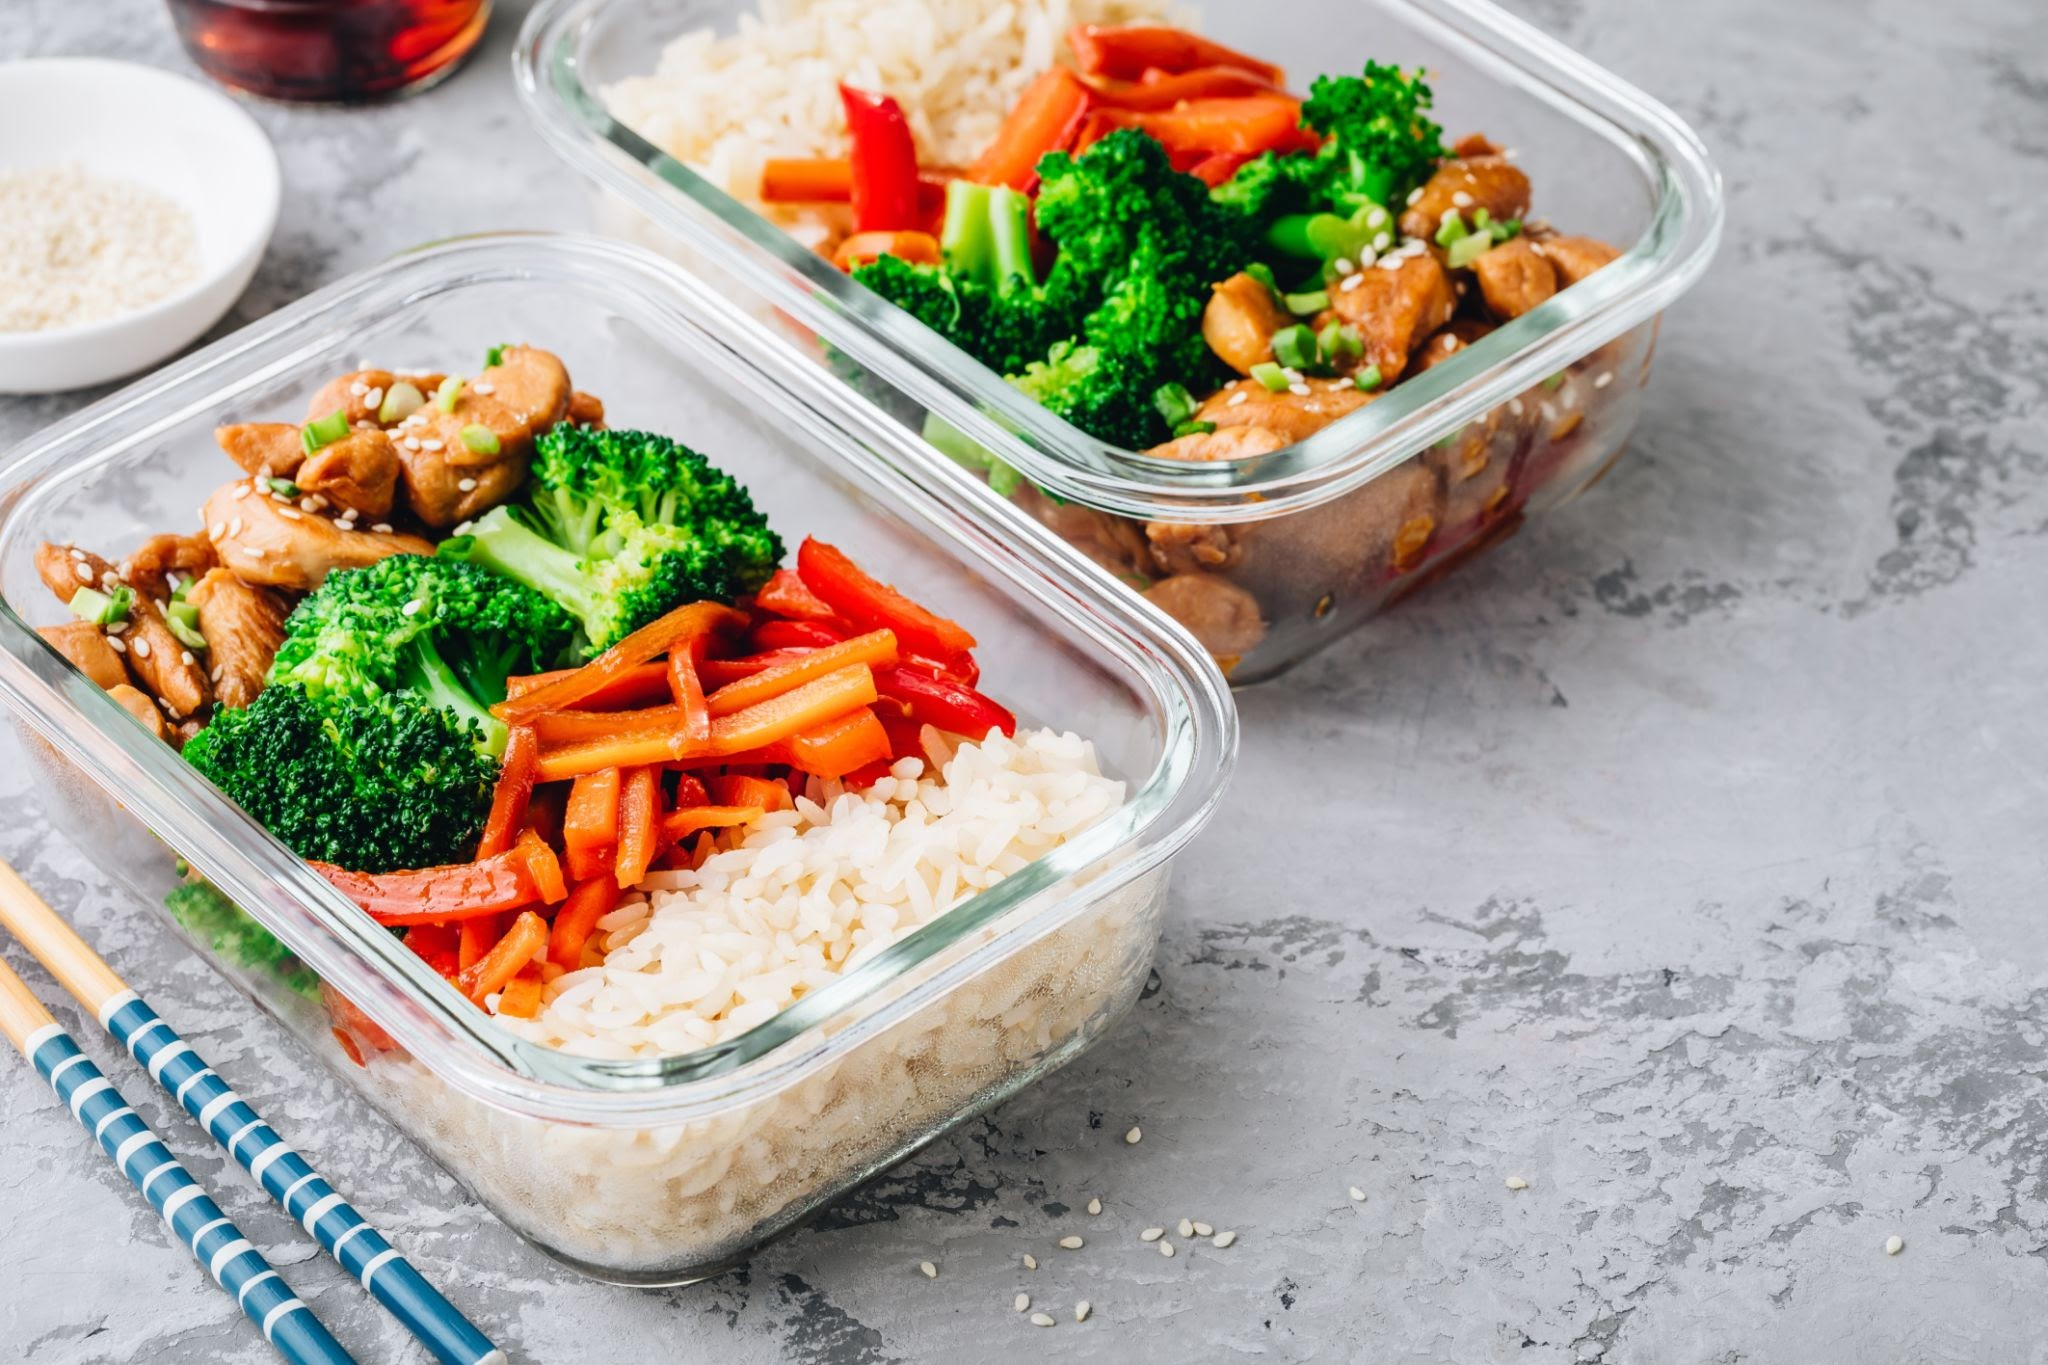

In [ ]:
import PIL.Image

img = PIL.Image.open("image.jpg")
img

Use the `gemini-1.5-flash` model and pass the image to the model with `generate_content`.

In [ ]:
model = genai.GenerativeModel("gemini-2.5-flash")

In [ ]:
response = model.generate_content(
    [
        "Descreva a imagem **em português**:",
        img
    ]
)
to_markdown(response.text)

> A imagem mostra dois recipientes de vidro transparentes repletos de uma refeição colorida e saudável. Cada recipiente contém uma generosa porção de arroz branco, pedaços de frango dourados em molho, brócolis vibrantes, e tiras de pimentão vermelho e laranja. Os pedaços de frango são polvilhados com sementes de gergelim branco e cebolinha verde picada.
> 
> Ao lado dos recipientes, repousam dois pares de pauzinhos de madeira, com detalhes em azul e branco nas pontas. Um pequeno pires branco à esquerda contém uma porção de sementes de gergelim, e um pequeno copo de vidro escuro com um líquido marrom está parcialmente visível no canto superior esquerdo. A superfície em que os recipientes estão dispostos é de concreto cinza texturizado, com algumas sementes de gergelim dispersas.
> 
> A iluminação destaca a frescura e a variedade dos ingredientes, criando uma cena apetitosa e organizada, perfeita para preparar refeições para a semana.

To provide both text and images in a prompt, pass a list containing the strings and images:

In [ ]:
response = model.generate_content(
    [
        "Escreva um post de blog curto e envolvente com base nesta foto. Ele deve incluir uma descrição da refeição na imagem e falar sobre a minha jornada com meal prep.",
        img,
    ],
    stream=True,
)
response.resolve()

In [ ]:
to_markdown(response.text)

> ## Meu Meal Prep Mágico: De Caos a Conquista!
> 
> Olha só essa obra de arte! Duas caixinhas de vidro cheias de cores vibrantes e promessas de sabor: arroz fofinho, brócolis crocante e suculento, cenoura em julienne adocicada e tirinhas de frango suculento em um molho delicioso, finalizado com um toque de gergelim tostado e cebolinha fresca. É de dar água na boca só de olhar, né?
> 
> E pensar que nem sempre foi assim! Minha jornada com o meal prep começou com um misto de desespero e esperança. Antigamente, minha rotina era uma correria sem fim, e na hora de comer, a preguiça ou a falta de tempo me levavam a opções menos saudáveis e mais caras. O resultado? Energia baixa, culpas gastronômicas e a sensação de que a alimentação saudável era um luxo inatingível.
> 
> Foi aí que decidi dar uma chance ao meal prep. No início, confesso, foi um desafio. A organização parecia impossível, a cozinha virava um campo de batalha e eu me perguntava se tudo isso valeria a pena. Mas, aos poucos, fui pegando o jeito. Descobri receitas práticas, truques para otimizar o tempo e, o mais importante, comecei a sentir os benefícios.
> 
> Hoje, olhar para essas caixinhas preparadas me enche de orgulho. Não é só sobre ter uma refeição pronta e deliciosa esperando por mim, é sobre autocuidado, sobre ter mais controle sobre a minha saúde e sobre me presentear com escolhas que me fazem bem. O meal prep se tornou meu aliado, transformando o caos da semana em momentos de sabor e praticidade.
> 
> E você, já se aventurou no mundo do meal prep? Compartilha sua experiência nos comentários! Quem sabe a gente não inspira mais gente a colocar essa magia em prática! ✨

## Chat conversations

Gemini enables you to have freeform conversations across multiple turns. The `ChatSession` class simplifies the process by managing the state of the conversation, so unlike with `generate_content`, you do not have to store the conversation history as a list.

Initialize the chat:

In [ ]:
model = genai.GenerativeModel("gemini-2.5-flash")
chat = model.start_chat(history=[])
chat

ChatSession(
    model=genai.GenerativeModel(
        model_name='models/gemini-2.5-flash',
        generation_config={},
        safety_settings={},
        tools=None,
        system_instruction=None,
        cached_content=None
    ),
    history=[]
)

The `ChatSession.send_message` method returns the same `GenerateContentResponse` type as <a href="https://github.com/google-gemini/generative-ai-python/blob/main/docs/api/google/generativeai/generate_text.md"><code>GenerativeModel.generate_content</code></a>. It also appends your message and the response to the chat history:

In [ ]:
response = chat.send_message(
    "O que é IA Generativa?"
)
to_markdown(response.text)

> A **IA Generativa** (Inteligência Artificial Generativa) é um tipo de inteligência artificial que tem a capacidade de **criar conteúdo novo e original** que nunca existiu antes. Ela faz isso aprendendo padrões, estilos e estruturas de grandes volumes de dados existentes (texto, imagens, áudio, vídeo, código, etc.) e, em seguida, usando esse conhecimento para gerar novas saídas que são coerentes e realistas com o que aprendeu.
> 
> Em termos mais simples:
> 
> 1.  **Aprendizagem de Padrões:** A IA é "treinada" com uma vasta quantidade de dados. Por exemplo, se for uma IA generativa de texto, ela lê milhões de artigos, livros, conversas; se for de imagem, ela vê milhões de fotos e obras de arte.
> 2.  **Geração de Conteúdo:** Com base nos padrões que aprendeu (como as palavras se juntam, como as formas e cores interagem), ela pode criar algo completamente novo. Você dá uma "solicitação" ou "prompt" (ex: "escreva um poema sobre gatos no espaço" ou "crie uma imagem de um cachorro lendo um livro") e ela gera uma resposta original.
> 
> **Características Principais:**
> 
> *   **Originalidade:** Não copia ou reproduz dados existentes, mas gera algo genuinamente novo.
> *   **Coerência e Realismo:** O conteúdo gerado é geralmente de alta qualidade e muitas vezes indistinguível de conteúdo criado por humanos.
> *   **Diversidade:** Pode gerar uma ampla gama de variações para uma mesma solicitação, demonstrando criatividade.
> *   **Modelos Mais Comuns:** As arquiteturas de IA generativa mais conhecidas incluem Redes Adversariais Generativas (GANs) e, mais recentemente, os Modelos de Transformadores (como os usados em grandes modelos de linguagem como o ChatGPT) e Modelos de Difusão (usados para geração de imagens).
> 
> **O que ela pode gerar?**
> 
> *   **Texto:** Artigos, emails, poemas, histórias, roteiros, código de programação, resumos, traduções (Ex: ChatGPT, Bard).
> *   **Imagens:** Fotos realistas, ilustrações artísticas, logos, designs (Ex: DALL-E, Midjourney, Stable Diffusion).
> *   **Áudio e Música:** Músicas originais, vozes sintéticas, efeitos sonoros.
> *   **Vídeo:** Clipes curtos, animações, efeitos visuais.
> *   **Código:** Gerar trechos de código em diversas linguagens de programação.
> *   **Modelos 3D:** Criar objetos e ambientes tridimensionais.
> 
> **Diferença da IA Tradicional:**
> 
> Enquanto a IA tradicional foca mais em **análise, classificação e previsão** (ex: reconhecer um rosto, prever um resultado, classificar spam), a IA Generativa foca em **criação e produção**. Ela não apenas entende os dados, mas também aprende a "falar" ou "desenhar" neles.
> 
> **Aplicações:**
> 
> A IA Generativa está revolucionando diversas indústrias, desde a criação de conteúdo e marketing, design de produtos, desenvolvimento de software, educação, entretenimento, até pesquisa científica. Seu potencial para aumentar a produtividade e a criatividade humana é enorme.

In [ ]:
chat.history

[parts {
   text: "O que é IA Generativa?"
 }
 role: "user",
 parts {
   text: "A **IA Generativa** (Inteligência Artificial Generativa) é um tipo de inteligência artificial que tem a capacidade de **criar conteúdo novo e original** que nunca existiu antes. Ela faz isso aprendendo padrões, estilos e estruturas de grandes volumes de dados existentes (texto, imagens, áudio, vídeo, código, etc.) e, em seguida, usando esse conhecimento para gerar novas saídas que são coerentes e realistas com o que aprendeu.\n\nEm termos mais simples:\n\n1.  **Aprendizagem de Padrões:** A IA é \"treinada\" com uma vasta quantidade de dados. Por exemplo, se for uma IA generativa de texto, ela lê milhões de artigos, livros, conversas; se for de imagem, ela vê milhões de fotos e obras de arte.\n2.  **Geração de Conteúdo:** Com base nos padrões que aprendeu (como as palavras se juntam, como as formas e cores interagem), ela pode criar algo completamente novo. Você dá uma \"solicitação\" ou \"prompt\" (ex: \"es

You can keep sending messages to continue the conversation. Use the `stream=True` argument to stream the chat:

In [ ]:
response = chat.send_message(
    "Me diga um algoritmo da IA Tradicional, um que faça previsão...", stream=True
)

for chunk in response:
    print(chunk.text)
    print("_" * 80)

Um algoritmo clássico da IA Tradicional que é amplamente utilizado para fazer previsões é a **Regressão Linear**.

### Regressão Linear

**O que é?**
A Regressão Linear é um dos algoritmos de aprend
________________________________________________________________________________
izado de máquina mais básicos e fundamentais. Seu objetivo é **modelar a relação entre uma variável dependente (o que você quer prever)** e **uma ou mais variáveis independentes (as características ou fatores que influenciam a previsão)**,
________________________________________________________________________________
 ajustando uma equação linear aos dados observados.

**Como funciona (ideia principal):**
Imagine que você tem um conjunto de pontos de dados e quer encontrar a "melhor linha reta" que passe por esses pontos. Essa
________________________________________________________________________________
 linha representa a relação entre as variáveis. Uma vez que você encontra essa linha, pode usá-la para p

[`genai.protos.Content`](https://github.com/google-gemini/generative-ai-python/blob/main/docs/api/google/generativeai/protos/Content.md) objects contain a list of [`genai.protos.Part`](https://github.com/google-gemini/generative-ai-python/blob/main/docs/api/google/generativeai/protos/Part.md) objects that each contain either a text (string) or inline_data ([`genai.protos.Blob`](https://github.com/google-gemini/generative-ai-python/blob/main/docs/api/google/generativeai/protos/Blob.md)), where a blob contains binary data and a `mime_type`. The chat history is available as a list of `genai.protos.Content` objects in `ChatSession.history`:

In [ ]:
for message in chat.history:
    display(to_markdown(f"**{message.role}**: {message.parts[0].text}"))

> **user**: O que é IA Generativa?

> **model**: A **IA Generativa** (Inteligência Artificial Generativa) é um tipo de inteligência artificial que tem a capacidade de **criar conteúdo novo e original** que nunca existiu antes. Ela faz isso aprendendo padrões, estilos e estruturas de grandes volumes de dados existentes (texto, imagens, áudio, vídeo, código, etc.) e, em seguida, usando esse conhecimento para gerar novas saídas que são coerentes e realistas com o que aprendeu.
> 
> Em termos mais simples:
> 
> 1.  **Aprendizagem de Padrões:** A IA é "treinada" com uma vasta quantidade de dados. Por exemplo, se for uma IA generativa de texto, ela lê milhões de artigos, livros, conversas; se for de imagem, ela vê milhões de fotos e obras de arte.
> 2.  **Geração de Conteúdo:** Com base nos padrões que aprendeu (como as palavras se juntam, como as formas e cores interagem), ela pode criar algo completamente novo. Você dá uma "solicitação" ou "prompt" (ex: "escreva um poema sobre gatos no espaço" ou "crie uma imagem de um cachorro lendo um livro") e ela gera uma resposta original.
> 
> **Características Principais:**
> 
> *   **Originalidade:** Não copia ou reproduz dados existentes, mas gera algo genuinamente novo.
> *   **Coerência e Realismo:** O conteúdo gerado é geralmente de alta qualidade e muitas vezes indistinguível de conteúdo criado por humanos.
> *   **Diversidade:** Pode gerar uma ampla gama de variações para uma mesma solicitação, demonstrando criatividade.
> *   **Modelos Mais Comuns:** As arquiteturas de IA generativa mais conhecidas incluem Redes Adversariais Generativas (GANs) e, mais recentemente, os Modelos de Transformadores (como os usados em grandes modelos de linguagem como o ChatGPT) e Modelos de Difusão (usados para geração de imagens).
> 
> **O que ela pode gerar?**
> 
> *   **Texto:** Artigos, emails, poemas, histórias, roteiros, código de programação, resumos, traduções (Ex: ChatGPT, Bard).
> *   **Imagens:** Fotos realistas, ilustrações artísticas, logos, designs (Ex: DALL-E, Midjourney, Stable Diffusion).
> *   **Áudio e Música:** Músicas originais, vozes sintéticas, efeitos sonoros.
> *   **Vídeo:** Clipes curtos, animações, efeitos visuais.
> *   **Código:** Gerar trechos de código em diversas linguagens de programação.
> *   **Modelos 3D:** Criar objetos e ambientes tridimensionais.
> 
> **Diferença da IA Tradicional:**
> 
> Enquanto a IA tradicional foca mais em **análise, classificação e previsão** (ex: reconhecer um rosto, prever um resultado, classificar spam), a IA Generativa foca em **criação e produção**. Ela não apenas entende os dados, mas também aprende a "falar" ou "desenhar" neles.
> 
> **Aplicações:**
> 
> A IA Generativa está revolucionando diversas indústrias, desde a criação de conteúdo e marketing, design de produtos, desenvolvimento de software, educação, entretenimento, até pesquisa científica. Seu potencial para aumentar a produtividade e a criatividade humana é enorme.

> **user**: Me diga um algoritmo da IA Tradicional, um que faça previsão...

> **model**: Um algoritmo clássico da IA Tradicional que é amplamente utilizado para fazer previsões é a **Regressão Linear**.
> 
> ### Regressão Linear
> 
> **O que é?**
> A Regressão Linear é um dos algoritmos de aprendizado de máquina mais básicos e fundamentais. Seu objetivo é **modelar a relação entre uma variável dependente (o que você quer prever)** e **uma ou mais variáveis independentes (as características ou fatores que influenciam a previsão)**, ajustando uma equação linear aos dados observados.
> 
> **Como funciona (ideia principal):**
> Imagine que você tem um conjunto de pontos de dados e quer encontrar a "melhor linha reta" que passe por esses pontos. Essa linha representa a relação entre as variáveis. Uma vez que você encontra essa linha, pode usá-la para prever o valor da variável dependente para novos dados (novas variáveis independentes) que você não viu antes.
> 
> **Matematicamente (forma mais simples):**
> A equação da Regressão Linear Simples (com apenas uma variável independente) é:
> `y = mx + b`
> 
> Onde:
> *   `y` é a **variável dependente** (o que queremos prever).
> *   `x` é a **variável independente** (a característica que usamos para prever `y`).
> *   `m` é o **coeficiente angular** (a inclinação da linha), que indica o quanto `y` muda para cada unidade de mudança em `x`.
> *   `b` é a **interceptação** (o ponto onde a linha cruza o eixo `y` quando `x` é 0).
> 
> **O objetivo do algoritmo é encontrar os valores ideais de `m` e `b`** que minimizem a "distância" ou o "erro" entre os valores previstos pela linha e os valores reais observados nos dados de treinamento. Isso é geralmente feito através de um método chamado "Mínimos Quadrados".
> 
> **Exemplo Prático (Previsão):**
> 
> Imagine que você quer **prever o preço de uma casa (`y`)** com base no seu **tamanho em metros quadrados (`x`)**.
> 
> 1.  **Dados de Treinamento:** Você coleta dados de casas que foram vendidas, registrando o tamanho e o preço de cada uma.
>     *   Casa 1: 100 m² - R$ 300.000
>     *   Casa 2: 120 m² - R$ 350.000
>     *   Casa 3: 80 m² - R$ 250.000
>     *   ...e assim por diante.
> 
> 2.  **Treinamento do Modelo:** O algoritmo de Regressão Linear analisará esses dados e encontrará a linha reta que melhor representa a relação entre o tamanho e o preço. Ou seja, ele determinará os valores de `m` e `b` para a equação `Preço = m * Tamanho + b`.
> 
> 3.  **Previsão:** Agora, se um cliente aparece com uma nova casa de 110 m² e pergunta qual seria um preço justo, o modelo pode usar o `x = 110` na equação aprendida (`Preço = m * 110 + b`) para **prever um preço estimado**.
> 
> **Por que é "Tradicional AI" e faz previsão?**
> 
> *   **Previsão Específica:** Diferente da IA Generativa que cria *novo conteúdo*, a Regressão Linear tem um objetivo muito específico: prever um valor numérico para uma variável alvo com base em outras variáveis. Ela não cria um texto, uma imagem ou uma música.
> *   **Análise de Padrões Existentes:** Ela analisa padrões *existentes* nos dados para encontrar uma relação e aplicá-la a novos dados. Ela "aprende" com o passado para "prever" o futuro dentro de um domínio bem definido.
> *   **Interpretabilidade:** É um modelo que geralmente permite uma boa interpretação da relação entre as variáveis, algo que pode ser mais difícil em modelos generativos complexos.
> 
> A Regressão Linear é a base para muitos modelos de previsão mais complexos e continua sendo uma ferramenta valiosa em campos como finanças, economia, medicina e engenharia.

## Count tokens

Large language models have a context window, and the context length is often measured in terms of the **number of tokens**. With the Gemini API, you can determine the number of tokens per any `genai.protos.Content` object. In the simplest case, you can pass a query string to the `GenerativeModel.count_tokens` method as follows:

In [ ]:
model.count_tokens("O que é IA Generativa?")

total_tokens: 7

Similarly, you can check `token_count` for your `ChatSession`:

In [ ]:
model.count_tokens(chat.history)

total_tokens: 1671